/opt/conda/envs/py310-scoob-env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


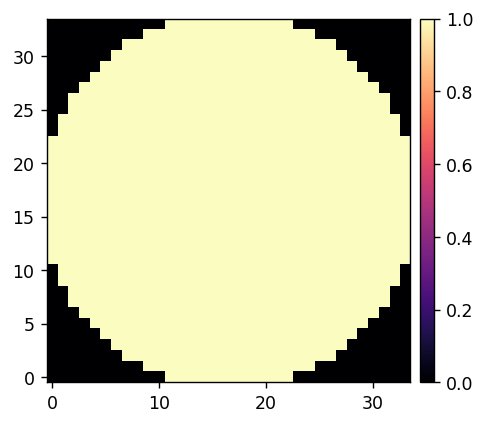

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

In [4]:
data_path = str(scoobscc.path)[:-9] + '/data_exp'
exp_path = data_path + '/20250610_scc_dig_mono'

data = utils.load_pickle(exp_path + '/dig01.pkl')

Text(0, 0.5, 'Contrast')

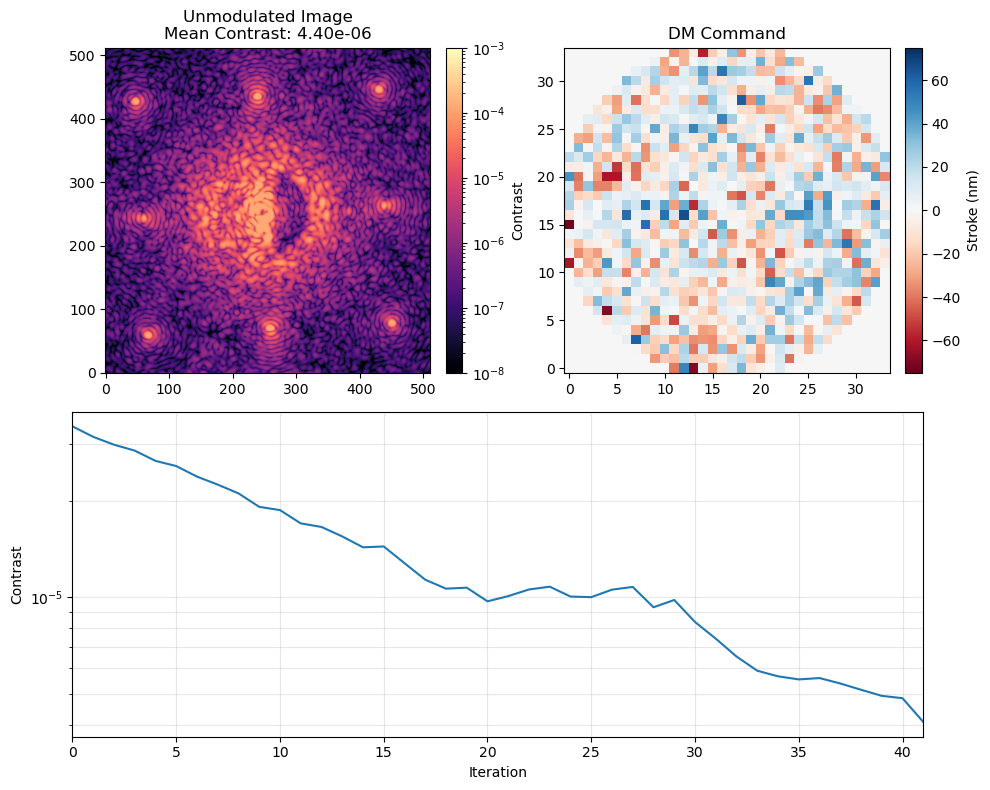

In [31]:
image = data['images_unmod'][-7]
command = data['commands'][-7]
mask = data['control_mask']
contrasts = [np.sqrt(np.mean(im[mask] ** 2)) for im in data['images_unmod']]

fig = plt.figure(figsize=(10, 8), layout='tight')
gs = plt.GridSpec(nrows=2, ncols=2)

ax1 = fig.add_subplot(gs[0, 0])
m = ax1.imshow(image, norm='log', cmap='magma', vmin=1e-8, vmax=1e-3)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Contrast')
ax1.set_title(f'Unmodulated Image\nMean Contrast: {np.sqrt(np.mean(image[mask] ** 2)):.2e}')

ax2 = fig.add_subplot(gs[0, 1])
m = ax2.imshow(command * 1e9, cmap='RdBu', vmin=-75, vmax=75)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Stroke (nm)')
ax2.set_title('DM Command')

ax3 = fig.add_subplot(gs[1, :])
ax3.semilogy(contrasts[:-7])
ax3.grid(which='both', axis='both', alpha=0.3)
ax3.set_xlim([0, len(contrasts[:-7]) - 1])
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Contrast')